In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

path = '/content/drive/MyDrive/airline_project/'

loyalty = pd.read_csv(path + 'Customer Loyalty History.csv')
flight  = pd.read_csv(path + 'Customer Flight Activity.csv')
cal     = pd.read_csv(path + 'Calendar.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')



print("=== DATA OVERVIEW ===")
print(f"Loyalty rows    : {len(loyalty):,}")
print(f"Flight rows     : {len(flight):,}")
print(f"Unique customers: {loyalty['Loyalty Number'].nunique():,}")
print(f"Flight years    : {flight['Year'].min()} - {flight['Year'].max()}")
print(f"Cancelled       : {loyalty['Cancellation Year'].notna().sum():,}")

print("\n=== LOYALTY COLUMNS ===")
print(loyalty.dtypes)

print("\n=== FLIGHT SAMPLE ===")
print(flight.head(3))

print("\n=== NULL CHECK ===")
print("Loyalty nulls:\n", loyalty.isnull().sum())
print("Flight nulls:\n", flight.isnull().sum())

=== DATA OVERVIEW ===
Loyalty rows    : 16,737
Flight rows     : 392,936
Unique customers: 16,737
Flight years    : 2017 - 2018
Cancelled       : 2,067

=== LOYALTY COLUMNS ===
Loyalty Number          int64
Country                object
Province               object
City                   object
Postal Code            object
Gender                 object
Education              object
Salary                float64
Marital Status         object
Loyalty Card           object
CLV                   float64
Enrollment Type        object
Enrollment Year         int64
Enrollment Month        int64
Cancellation Year     float64
Cancellation Month    float64
dtype: object

=== FLIGHT SAMPLE ===
   Loyalty Number  Year  Month  Total Flights  Distance  Points Accumulated  \
0          100590  2018      6             12     15276             22914.0   
1          100590  2018      7             12      9168             13752.0   
2          100590  2018      5              4      6504              

** EDA for Customer Loyalty History **


In [ ]:
loyalty.shape

(16737, 16)

In [ ]:
loyalty.isnull().sum()

,0
Loyalty Number,0
Country,0
Province,0
City,0
Postal Code,0
Gender,0
Education,0
Salary,4238
Marital Status,0
Loyalty Card,0


In [ ]:
loyalty['Cancellation Month'].unique()


array([nan,  1., 12.,  4.,  2.,  7., 11.,  5.,  6., 10.,  8.,  9.,  3.])

In [ ]:
loyalty['Cancellation Year'].unique()

array([  nan, 2018., 2015., 2017., 2014., 2016., 2013.])

In [ ]:
loyalty['Salary'].unique()

array([ 83236.,     nan, 103495., ...,  76178.,  91970., -57297.])

Convert nagetive salary into positive


In [ ]:
loyalty[loyalty['Salary'] < 0].head()

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
1082,542976,Canada,Quebec,Montreal,H2Y 4R4,Male,High School or Below,-49830.0,Divorced,Star,24127.50,2018 Promotion,2018,3,NaN,NaN
1894,959977,Canada,British Columbia,Vancouver,V5R 1W3,Female,Bachelor,-12497.0,Married,Aurora,9453.00,2018 Promotion,2018,3,NaN,NaN
2471,232755,Canada,British Columbia,Vancouver,V1E 4R6,Female,Bachelor,-46683.0,Single,Nova,4787.81,2018 Promotion,2018,3,NaN,NaN
3575,525245,Canada,British Columbia,Victoria,V10 6T5,Male,Bachelor,-45962.0,Married,Star,2402.33,2018 Promotion,2018,3,NaN,NaN
3932,603070,Canada,British Columbia,West Vancouver,V6V 8Z3,Female,Bachelor,-19325.0,Single,Star,2893.74,2018 Promotion,2018,3,NaN,NaN


In [ ]:
print(loyalty[loyalty['Salary'] < 0][['Loyalty Number', 'Salary']].to_string())

       Loyalty Number   Salary
1082           542976 -49830.0
1894           959977 -12497.0
2471           232755 -46683.0
3575           525245 -45962.0
3932           603070 -19325.0
4712           491242 -43234.0
6560           115505 -10605.0
6570           430398 -17534.0
7373           152016 -58486.0
8576           194065 -31911.0
8767           212128 -49001.0
10232          790475 -34079.0
11635          366599  -9081.0
12596          436087 -46470.0
13564          364596 -26322.0
14327          239955 -47310.0
14355          347013 -39503.0
15416          729561 -19332.0
16431          734647 -46303.0
16735          906428 -57297.0


In [ ]:
loyalty['Salary'] = loyalty['Salary'].abs()

In [ ]:
print(loyalty[loyalty['Salary'] < 0][['Loyalty Number', 'Salary']].to_string())

Empty DataFrame
Columns: [Loyalty Number, Salary]
Index: []


Fill null valuse of salary with median


In [ ]:

tier_median = loyalty.groupby('Loyalty Card')['Salary'].transform('median')
loyalty['Salary'] = loyalty['Salary'].fillna(tier_median)

print(f"Null remaining: {loyalty['Salary'].isna().sum()}")
print(loyalty.groupby('Loyalty Card')['Salary'].median())

Null remaining: 0
Loyalty Card
Aurora    74123.0
Nova      73327.0
Star      73135.0
Name: Salary, dtype: float64


In [ ]:
loyalty['Salary'].isnull().sum()

np.int64(0)

In [ ]:
loyalty['is_cancelled'] = loyalty['Cancellation Year'].notna().astype(int)


**EDA for Customer flight Activity Data**

In [ ]:
flight.shape

(392936, 8)

In [ ]:
flight.head()

,Loyalty Number,Year,Month,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
0,100590,2018,6,12,15276,22914.0,0,0
1,100590,2018,7,12,9168,13752.0,0,0
2,100590,2018,5,4,6504,9756.0,0,0
3,100590,2018,10,0,0,0.0,512,92
4,100590,2018,2,0,0,0.0,0,0


In [ ]:
flight.columns

Index(['Loyalty Number', 'Year', 'Month', 'Total Flights', 'Distance',
       'Points Accumulated', 'Points Redeemed', 'Dollar Cost Points Redeemed'],
      dtype='object')

In [ ]:
flight.isnull().sum()

,0
Loyalty Number,0
Year,0
Month,0
Total Flights,0
Distance,0
Points Accumulated,0
Points Redeemed,0
Dollar Cost Points Redeemed,0


In [ ]:
flight.dtypes

,0
Loyalty Number,int64
Year,int64
Month,int64
Total Flights,int64
Distance,int64
Points Accumulated,float64
Points Redeemed,int64
Dollar Cost Points Redeemed,int64


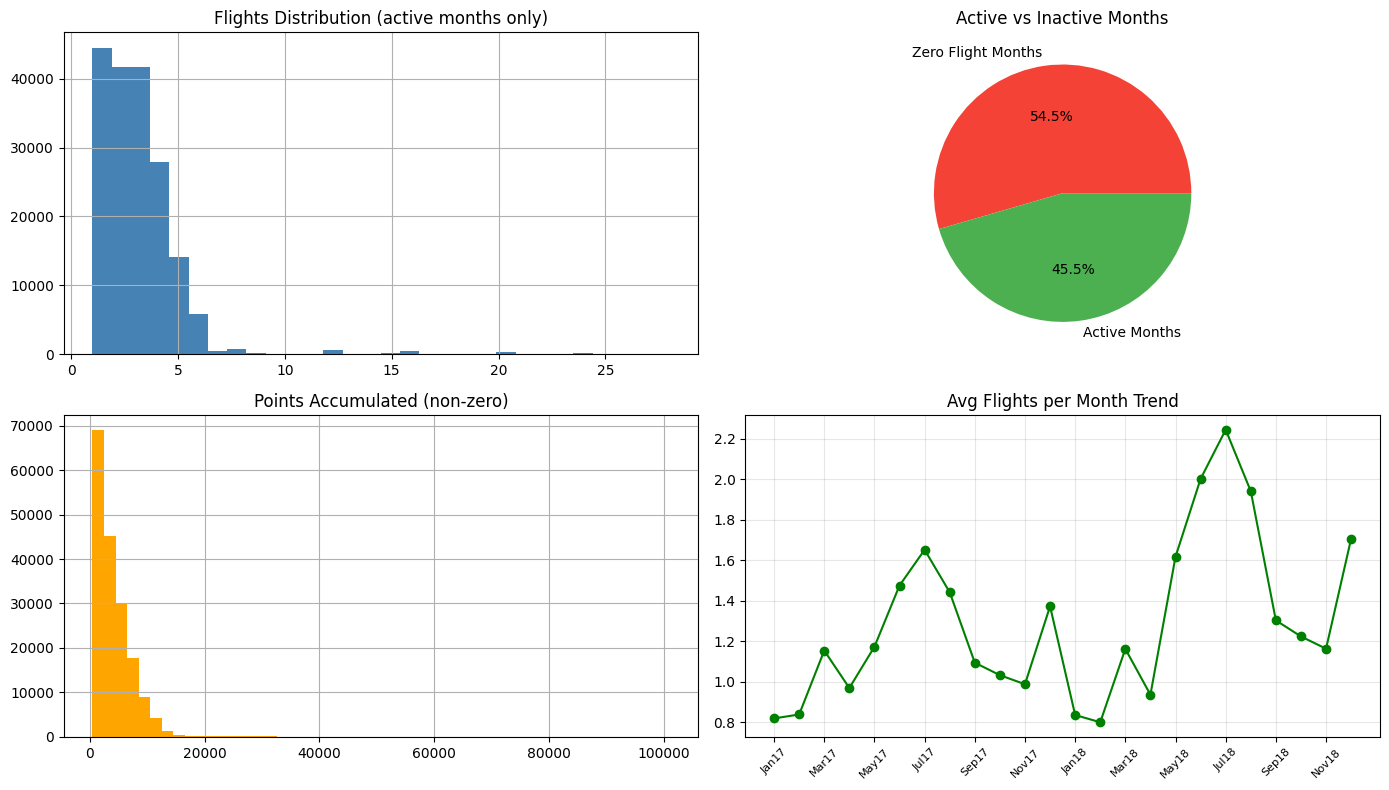

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 8))


flight[flight['Total Flights']>0]['Total Flights'].hist(
    bins=30, ax=axes[0,0], color='steelblue')
axes[0,0].set_title("Flights Distribution (active months only)")


labels = ['Zero Flight Months', 'Active Months']
values = [(flight['Total Flights']==0).sum(),
          (flight['Total Flights']>0).sum()]
axes[0,1].pie(values, labels=labels, autopct='%1.1f%%',
              colors=['#F44336','#4CAF50'])
axes[0,1].set_title("Active vs Inactive Months")


flight[flight['Points Accumulated']>0]['Points Accumulated'].hist(
    bins=50, ax=axes[1,0], color='orange')
axes[1,0].set_title("Points Accumulated (non-zero)")


monthly = flight.groupby(['Year','Month'])['Total Flights'].mean().reset_index()
axes[1,1].plot(range(24), monthly['Total Flights'], marker='o', color='green')
axes[1,1].set_xticks(range(0,24,2))
axes[1,1].set_xticklabels(['Jan17','Mar17','May17','Jul17','Sep17','Nov17',
                            'Jan18','Mar18','May18','Jul18','Sep18','Nov18'],
                           rotation=45, fontsize=8)
axes[1,1].set_title("Avg Flights per Month Trend")
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
loyalty['tenure_months'] = (
    (2018 - loyalty['Enrollment Year']) * 12 +
    (6 - loyalty['Enrollment Month'])
).clip(lower=1)


loyalty['card_rank'] = loyalty['Loyalty Card'].map(
    {'Star': 1, 'Nova': 2, 'Aurora': 3}
)

In [ ]:

customer_activity = flight.groupby('Loyalty Number').agg(
    total_flights = ('Total Flights', 'sum'),
    active_months = ('Total Flights', lambda x: (x>0).sum()),
).reset_index()

print("Never flew (0 flights total):")
print((customer_activity['total_flights']==0).sum())

# Active in 2017 but zero in 2018
flights_2017 = flight[flight['Year']==2017].groupby('Loyalty Number')['Total Flights'].sum()
flights_2018 = flight[flight['Year']==2018].groupby('Loyalty Number')['Total Flights'].sum()
print("\nActive in 2017 but zero flights in 2018:")
print(((flights_2017>0) & (flights_2018==0)).sum())

# Active in H1 2018 but zero in H2 2018
h1 = flight[(flight['Year']==2018) & (flight['Month']<=6)].groupby('Loyalty Number')['Total Flights'].sum()
h2 = flight[(flight['Year']==2018) & (flight['Month']>6)].groupby('Loyalty Number')['Total Flights'].sum()
print("\nActive in H1 2018 but zero in H2 2018:")
print(((h1>0) & (h2==0)).sum())

# Formally cancelled
print("\nFormally cancelled:")
print(loyalty['is_cancelled'].sum())

Never flew (0 flights total):
1570

Active in 2017 but zero flights in 2018:
553

Active in H1 2018 but zero in H2 2018:
346

Formally cancelled:
2067


In [ ]:
never_flew = customer_activity[customer_activity['total_flights']==0]['Loyalty Number']

flights_2017 = flight[flight['Year']==2017].groupby('Loyalty Number')['Total Flights'].sum()
flights_2018 = flight[flight['Year']==2018].groupby('Loyalty Number')['Total Flights'].sum()
h1 = flight[(flight['Year']==2018)&(flight['Month']<=6)].groupby('Loyalty Number')['Total Flights'].sum()
h2 = flight[(flight['Year']==2018)&(flight['Month']>6)].groupby('Loyalty Number')['Total Flights'].sum()

loyalty['behavioral_churn'] = (
    ((flights_2017.reindex(loyalty['Loyalty Number'].values, fill_value=0).values > 0) &
     (flights_2018.reindex(loyalty['Loyalty Number'].values, fill_value=0).values == 0)) |
    ((h1.reindex(loyalty['Loyalty Number'].values, fill_value=0).values > 0) &
     (h2.reindex(loyalty['Loyalty Number'].values, fill_value=0).values == 0))
).astype(int)

loyalty['churn'] = (
    (loyalty['is_cancelled'] == 1) |
    (loyalty['behavioral_churn'] == 1)
).astype(int)


loyalty['never_flew'] = loyalty['Loyalty Number'].isin(never_flew).astype(int)

print("Formally cancelled  :", loyalty['is_cancelled'].sum())
print("Behavioral churn    :", loyalty['behavioral_churn'].sum())
print("Total churn         :", loyalty['churn'].sum())
print("Never flew (exclude):", loyalty['never_flew'].sum())
print("Churn rate          :", f"{loyalty[loyalty['never_flew']==0]['churn'].mean()*100:.1f}%")

Formally cancelled  : 2067
Behavioral churn    : 899
Total churn         : 2175
Never flew (exclude): 1570
Churn rate          : 8.1%


In [ ]:
loyalty.head()

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,...,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month,is_cancelled,tenure_months,card_rank,behavioral_churn,churn,never_flew
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,...,2016,2,NaN,NaN,0,28,1,0,0,0
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,73135.0,Divorced,Star,...,2016,3,NaN,NaN,0,27,1,0,0,0
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,73135.0,Single,Star,...,2014,7,2018.0,1.0,1,47,1,1,1,0
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,73135.0,Single,Star,...,2013,2,NaN,NaN,0,64,1,0,0,0
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,...,2014,10,NaN,NaN,0,44,1,0,0,0


In [ ]:
# Split data into feature window and label window
feature_flight = flight[
    ~((flight['Year'] == 2018) & (flight['Month'] >= 7))
].copy()

label_flight = flight[
    (flight['Year'] == 2018) & (flight['Month'] >= 7)
].copy()

print("Feature window (Jan2017 - Jun2018):", len(feature_flight), "rows")
print("Label window   (Jul2018 - Dec2018):", len(label_flight), "rows")

Feature window (Jan2017 - Jun2018): 291530 rows
Label window   (Jul2018 - Dec2018): 101406 rows


In [ ]:

agg = feature_flight.groupby('Loyalty Number').agg(
    total_flights       = ('Total Flights', 'sum'),
    total_distance      = ('Distance', 'sum'),
    total_pts_earned    = ('Points Accumulated', 'sum'),
    total_pts_redeemed  = ('Points Redeemed', 'sum'),
    total_dollar_redeem = ('Dollar Cost Points Redeemed', 'sum'),
    active_months       = ('Total Flights', lambda x: (x > 0).sum()),
    zero_months         = ('Total Flights', lambda x: (x == 0).sum()),
    max_flights_month   = ('Total Flights', 'max'),
    avg_flights_month   = ('Total Flights', 'mean'),
    std_flights_month   = ('Total Flights', 'std'),
).reset_index()

agg['std_flights_month'] = agg['std_flights_month'].fillna(0)
print("Agg shape:", agg.shape)
print(agg.head(3))

Agg shape: (16737, 11)
   Loyalty Number  total_flights  total_distance  total_pts_earned  \
0          100018             29           44813           44813.0   
1          100102             34           50123           50123.0   
2          100140             36           52368           52368.0   

   total_pts_redeemed  total_dollar_redeem  active_months  zero_months  \
0                1128                  203             13            5   
1                1195                  215             12            6   
2                 593                  107             13            5   

   max_flights_month  avg_flights_month  std_flights_month  
0                  4           1.611111           1.377931  
1                  5           1.888889           1.604732  
2                  5           2.000000           1.714986  


In [ ]:
# Months since last flight (from June 2018)
last_active = feature_flight[feature_flight['Total Flights'] > 0].copy()
last_active['date_num'] = last_active['Year'] * 100 + last_active['Month']

last_act = last_active.groupby('Loyalty Number')['date_num'].max().reset_index()
last_act.columns = ['Loyalty Number', 'last_active_date']

def months_ago(date_num):
    yr = date_num // 100
    mo = date_num % 100
    return (2018 - yr) * 12 + (6 - mo)

last_act['recency_months'] = last_act['last_active_date'].apply(months_ago)

agg = agg.merge(last_act[['Loyalty Number', 'recency_months']],
                on='Loyalty Number', how='left')

# Never flew = max recency (18 months)
agg['recency_months'] = agg['recency_months'].fillna(18)

print("Recency stats:")
print(agg['recency_months'].describe().round(2))

Recency stats:
count    16737.00
mean         3.88
std          6.66
min          0.00
25%          0.00
50%          1.00
75%          3.00
max         18.00
Name: recency_months, dtype: float64


In [ ]:

agg['engagement_ratio'] = agg['active_months'] / 18


agg['redemption_rate'] = (
    agg['total_pts_redeemed'] / (agg['total_pts_earned'] + 1)
)

agg['avg_dist_per_flight'] = (
    agg['total_distance'] / (agg['total_flights'] + 1)
)

print("New features:")
print(agg[['engagement_ratio', 'redemption_rate',
           'avg_dist_per_flight']].describe().round(3))

New features:
       engagement_ratio  redemption_rate  avg_dist_per_flight
count         16737.000        16737.000            16737.000
mean              0.426            0.262             1186.334
std               0.265           11.521              573.841
min               0.000            0.000                0.000
25%               0.167            0.000             1125.071
50%               0.500            0.010             1375.081
75%               0.611            0.024             1549.407
max               1.500          743.000             2360.640


In [ ]:

flights_2017 = feature_flight[
    feature_flight['Year'] == 2017
].groupby('Loyalty Number')['Total Flights'].sum().reset_index()
flights_2017.columns = ['Loyalty Number', 'flights_2017']

flights_h1_2018 = feature_flight[
    (feature_flight['Year'] == 2018) &
    (feature_flight['Month'] <= 6)
].groupby('Loyalty Number')['Total Flights'].sum().reset_index()
flights_h1_2018.columns = ['Loyalty Number', 'flights_h1_2018']

agg = agg.merge(flights_2017, on='Loyalty Number', how='left')
agg = agg.merge(flights_h1_2018, on='Loyalty Number', how='left')
agg['flights_2017']    = agg['flights_2017'].fillna(0)
agg['flights_h1_2018'] = agg['flights_h1_2018'].fillna(0)


agg['activity_trend'] = agg['flights_h1_2018'] - (agg['flights_2017'] / 2)

print("Activity trend stats:")
print(agg['activity_trend'].describe().round(2))
print("Declining customers:", (agg['activity_trend'] < 0).sum())
print("Growing customers  :", (agg['activity_trend'] > 0).sum())

Activity trend stats:
count    16737.00
mean         0.71
std          6.84
min        -23.50
25%         -3.00
50%          0.00
75%          3.00
max         51.00
Name: activity_trend, dtype: float64
Declining customers: 6845
Growing customers  : 6675


In [ ]:
# Flight activity by season
feature_flight['season'] = feature_flight['Month'].map({
    12:'winter', 1:'winter',  2:'winter',
    3:'spring',  4:'spring',  5:'spring',
    6:'summer',
    7:'fall',    8:'fall',    9:'fall',
    10:'fall',   11:'fall'
})

season_pivot = feature_flight.pivot_table(
    index='Loyalty Number',
    columns='season',
    values='Total Flights',
    aggfunc='sum'
).fillna(0).reset_index()
season_pivot.columns.name = None

agg = agg.merge(season_pivot, on='Loyalty Number', how='left')
for col in ['fall', 'spring', 'summer', 'winter']:
    if col in agg.columns:
        agg[col] = agg[col].fillna(0)

print("Seasonal features added")
print(agg[['fall','spring','summer','winter']].describe().round(2))

Seasonal features added
           fall    spring    summer    winter
count  16737.00  16737.00  16737.00  16737.00
mean       5.91      6.89      3.43      4.49
std        5.06      5.13      3.84      3.69
min        0.00      0.00      0.00      0.00
25%        0.00      3.00      0.00      1.00
50%        6.00      7.00      3.00      4.00
75%       10.00     11.00      6.00      7.00
max       31.00     35.00     32.00     26.00


In [ ]:

demo_cols = ['Loyalty Number', 'Gender', 'Education', 'Salary',
             'Marital Status', 'Loyalty Card', 'CLV',
             'Enrollment Type', 'tenure_months', 'card_rank',
             'churn', 'is_cancelled', 'behavioral_churn', 'never_flew']

master = loyalty[demo_cols].merge(agg, on='Loyalty Number', how='left')


flight_cols = [c for c in agg.columns if c != 'Loyalty Number']
for col in flight_cols:
    if col in master.columns:
        master[col] = master[col].fillna(0)

master['gender_enc']  = (master['Gender'] == 'Female').astype(int)
master['edu_enc']     = master['Education'].map({
    'High School or Below': 0, 'College': 1,
    'Bachelor': 2, 'Master': 3, 'Doctor': 4
})
master['marital_enc'] = master['Marital Status'].map(
    {'Single': 0, 'Divorced': 1, 'Married': 2}
)
master['promo_enc']   = (
    master['Enrollment Type'] == '2018 Promotion'
).astype(int)

print("Master shape:", master.shape)
print("Columns:", master.columns.tolist())
print("\nNull check:")
print(master.isnull().sum()[master.isnull().sum() > 0])

Master shape: (16737, 39)
Columns: ['Loyalty Number', 'Gender', 'Education', 'Salary', 'Marital Status', 'Loyalty Card', 'CLV', 'Enrollment Type', 'tenure_months', 'card_rank', 'churn', 'is_cancelled', 'behavioral_churn', 'never_flew', 'total_flights', 'total_distance', 'total_pts_earned', 'total_pts_redeemed', 'total_dollar_redeem', 'active_months', 'zero_months', 'max_flights_month', 'avg_flights_month', 'std_flights_month', 'recency_months', 'engagement_ratio', 'redemption_rate', 'avg_dist_per_flight', 'flights_2017', 'flights_h1_2018', 'activity_trend', 'fall', 'spring', 'summer', 'winter', 'gender_enc', 'edu_enc', 'marital_enc', 'promo_enc']

Null check:
Series([], dtype: int64)


In [ ]:
# Final feature list for model
FEATURES = [
    # Flight behavior
    'total_flights', 'total_distance', 'total_pts_earned',
    'total_pts_redeemed', 'total_dollar_redeem',
    'active_months', 'zero_months', 'max_flights_month',
    'avg_flights_month', 'std_flights_month',
    # Recency & Engagement
    'recency_months', 'engagement_ratio', 'redemption_rate',
    'avg_dist_per_flight', 'activity_trend',
    # Trend
    'flights_2017', 'flights_h1_2018',
    # Seasonal
    'fall', 'spring', 'summer', 'winter',
    # Demographics
    'CLV', 'Salary', 'tenure_months', 'card_rank',
    'gender_enc', 'edu_enc', 'marital_enc', 'promo_enc'
]

FEATURES = [f for f in FEATURES if f in master.columns]
print(f"Total features: {len(FEATURES)}")
print(FEATURES)

Total features: 29
['total_flights', 'total_distance', 'total_pts_earned', 'total_pts_redeemed', 'total_dollar_redeem', 'active_months', 'zero_months', 'max_flights_month', 'avg_flights_month', 'std_flights_month', 'recency_months', 'engagement_ratio', 'redemption_rate', 'avg_dist_per_flight', 'activity_trend', 'flights_2017', 'flights_h1_2018', 'fall', 'spring', 'summer', 'winter', 'CLV', 'Salary', 'tenure_months', 'card_rank', 'gender_enc', 'edu_enc', 'marital_enc', 'promo_enc']


In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Exclude never flew from segmentation
seg_data = master[master['never_flew'] == 0].copy()

SEG_FEATS = [
    'engagement_ratio', 'recency_months', 'total_flights',
    'CLV', 'activity_trend', 'redemption_rate',
    'avg_dist_per_flight', 'tenure_months'
]

X_seg = seg_data[SEG_FEATS].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_seg)

# Find best K
print("Finding optimal K...")
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    print(f"K={k}: Silhouette={sil:.4f}")

Finding optimal K...
K=2: Silhouette=0.5325
K=3: Silhouette=0.3787
K=4: Silhouette=0.3818
K=5: Silhouette=0.3805
K=6: Silhouette=0.2525


In [ ]:
# K=3 for business clarity
km3 = KMeans(n_clusters=3, random_state=42, n_init=10)
seg_data['seg_id'] = km3.fit_predict(X_scaled)

# Profile each segment
profile = seg_data.groupby('seg_id').agg(
    count          = ('Loyalty Number', 'count'),
    avg_flights    = ('total_flights', 'mean'),
    avg_engagement = ('engagement_ratio', 'mean'),
    avg_recency    = ('recency_months', 'mean'),
    avg_clv        = ('CLV', 'mean'),
    avg_redemption = ('redemption_rate', 'mean'),
    churn_rate     = ('churn', 'mean'),
).round(3)

print(profile)

        count  avg_flights  avg_engagement  avg_recency   avg_clv  \
seg_id                                                              
0       10349       28.547           0.602        0.820  7966.771   
1        3467       14.622           0.256        1.282  7860.035   
2        1351        0.500           0.012       17.620  8056.861   

        avg_redemption  churn_rate  
seg_id                              
0                0.018       0.046  
1                0.017       0.167  
2                2.407       0.129  


In [ ]:
# Name segments based on engagement + recency
seg_names = {}
for sid in range(3):
    row = profile.loc[sid]
    if row['avg_engagement'] > 0.4 and row['avg_recency'] < 3:
        seg_names[sid] = 'Core Flyers'
    elif row['avg_recency'] > 12:
        seg_names[sid] = 'Silent Attritors'
    else:
        seg_names[sid] = 'Drifting Loyalists'

seg_data['segment'] = seg_data['seg_id'].map(seg_names)

# Merge back to master
master = master.merge(
    seg_data[['Loyalty Number', 'segment']],
    on='Loyalty Number', how='left'
)
master['segment'] = master['segment'].fillna('Never Active')

print("\nFinal Segments:")
for seg in master['segment'].unique():
    grp = master[master['segment'] == seg]
    print(f"\n{seg}:")
    print(f"  Count     : {len(grp):,}")
    print(f"  Churn rate: {grp['churn'].mean()*100:.1f}%")
    print(f"  Avg CLV   : ${grp['CLV'].mean():,.0f}")


Final Segments:

Core Flyers:
  Count     : 10,349
  Churn rate: 4.6%
  Avg CLV   : $7,967

Drifting Loyalists:
  Count     : 3,467
  Churn rate: 16.7%
  Avg CLV   : $7,860

Silent Attritors:
  Count     : 1,351
  Churn rate: 12.9%
  Avg CLV   : $8,057

Never Active:
  Count     : 1,570
  Churn rate: 60.6%
  Avg CLV   : $8,361


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (classification_report, roc_auc_score,
                             f1_score, precision_score, recall_score)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# Exclude never flew from model
model_data = master[master['never_flew'] == 0].copy()

X = model_data[FEATURES].fillna(0)
y = model_data['churn']

print(f"Churned    : {y.sum():,} ({y.mean()*100:.1f}%)")
print(f"Not churned: {(y==0).sum():,}")

# Balance classes with SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)
X_bal, y_bal = smote.fit_resample(X, y)
print(f"\nAfter SMOTE:")
print(f"Churned    : {y_bal.sum():,}")
print(f"Not churned: {(y_bal==0).sum():,}")

Churned    : 1,224 (8.1%)
Not churned: 13,943

After SMOTE:
Churned    : 13,943
Not churned: 13,943


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, roc_auc_score,
                             f1_score, precision_score, recall_score)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import numpy as np


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=== TRAINING ALL MODELS ===\n")

=== TRAINING ALL MODELS ===



In [ ]:
# XGBoost - RandomizedSearchCV
xgb_params = {
    'n_estimators'     : [200, 300, 400, 500],
    'max_depth'        : [3, 4, 5],
    'learning_rate'    : [0.01, 0.03, 0.05, 0.1],
    'subsample'        : [0.7, 0.8, 0.9],
    'colsample_bytree' : [0.7, 0.75, 0.8],
    'reg_alpha'        : [0, 0.1, 0.5],
    'reg_lambda'       : [1.0, 1.5, 2.0],
    'min_child_weight' : [3, 5, 7]
}

xgb_base = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

xgb_search = RandomizedSearchCV(
    xgb_base, xgb_params,
    n_iter=30,
    cv=skf,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_bal, y_bal)
best_xgb = xgb_search.best_estimator_

print("\nBest XGBoost params:")
print(xgb_search.best_params_)
print(f"Best CV F1: {xgb_search.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best XGBoost params:
{'subsample': 0.9, 'reg_lambda': 1.5, 'reg_alpha': 0.1, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best CV F1: 0.9716


In [ ]:
from lightgbm import LGBMClassifier


lgbm_params = {
    'n_estimators'    : [200, 300, 400, 500],
    'max_depth'       : [4, 5, 6, -1],
    'learning_rate'   : [0.01, 0.03, 0.05, 0.1],
    'num_leaves'      : [20, 31, 50, 70],
    'subsample'       : [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'reg_alpha'       : [0, 0.1, 0.5],
    'reg_lambda'      : [0, 1.0, 2.0],
    'min_child_samples': [10, 20, 30]
}

lgbm_base = LGBMClassifier(
    random_state=42,
    verbosity=-1
)

lgbm_search = RandomizedSearchCV(
    lgbm_base, lgbm_params,
    n_iter=30,
    cv=skf,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

lgbm_search.fit(X_bal, y_bal)
best_lgbm = lgbm_search.best_estimator_

print("Best LightGBM params:")
print(lgbm_search.best_params_)
print(f"Best CV F1: {lgbm_search.best_score_:.4f}")



Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best LightGBM params:
{'subsample': 0.7, 'reg_lambda': 0, 'reg_alpha': 0.5, 'num_leaves': 50, 'n_estimators': 400, 'min_child_samples': 20, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.7}
Best CV F1: 0.9738


NameError: name 'precision_recall_curve' is not defined

In [ ]:
from sklearn.metrics import precision_recall_curve, roc_auc_score, f1_score, precision_score, recall_score

# Initialize results if not exists
if 'results' not in dir():
    results = {}

# Add LightGBM to results
y_prob_lgbm = best_lgbm.predict_proba(X)[:, 1]
prec, rec, thresh = precision_recall_curve(y, y_prob_lgbm)
f1_vals = 2 * (prec * rec) / (prec + rec + 1e-8)
best_thresh_lgbm = thresh[f1_vals.argmax()]
y_pred_lgbm = (y_prob_lgbm >= best_thresh_lgbm).astype(int)

results['LightGBM'] = {
    'model'    : best_lgbm,
    'y_prob'   : y_prob_lgbm,
    'threshold': best_thresh_lgbm,
    'auc'      : roc_auc_score(y, y_prob_lgbm),
    'f1'       : f1_score(y, y_pred_lgbm),
    'precision': precision_score(y, y_pred_lgbm),
    'recall'   : recall_score(y, y_pred_lgbm)
}

print(f"LightGBM Results:")
print(f"AUC      : {results['LightGBM']['auc']:.4f}")
print(f"F1       : {results['LightGBM']['f1']:.4f}")
print(f"Precision: {results['LightGBM']['precision']:.4f}")
print(f"Recall   : {results['LightGBM']['recall']:.4f}")

LightGBM Results:
AUC      : 0.9970
F1       : 0.9427
Precision: 0.9657
Recall   : 0.9208


In [ ]:
# Random Forest - RandomizedSearchCV
rf_params = {
    'n_estimators'      : [200, 300, 400],
    'max_depth'         : [6, 8, 10, None],
    'min_samples_split' : [5, 10, 15],
    'min_samples_leaf'  : [2, 4, 6],
    'max_features'      : ['sqrt', 'log2'],
    'class_weight'      : ['balanced']
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

rf_search = RandomizedSearchCV(
    rf_base, rf_params,
    n_iter=20,
    cv=skf,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_bal, y_bal)
best_rf = rf_search.best_estimator_

print("\nBest Random Forest params:")
print(rf_search.best_params_)
print(f"Best CV F1: {rf_search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Random Forest params:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None, 'class_weight': 'balanced'}
Best CV F1: 0.9661


In [ ]:

y_prob_xgb = best_xgb.predict_proba(X)[:, 1]
prec, rec, thresh = precision_recall_curve(y, y_prob_xgb)
f1_vals = 2 * (prec * rec) / (prec + rec + 1e-8)
best_thresh_xgb = thresh[f1_vals.argmax()]
y_pred_xgb = (y_prob_xgb >= best_thresh_xgb).astype(int)

results['XGBoost'] = {
    'model'    : best_xgb,
    'y_prob'   : y_prob_xgb,
    'threshold': best_thresh_xgb,
    'auc'      : roc_auc_score(y, y_prob_xgb),
    'f1'       : f1_score(y, y_pred_xgb),
    'precision': precision_score(y, y_pred_xgb),
    'recall'   : recall_score(y, y_pred_xgb)
}


y_prob_rf = best_rf.predict_proba(X)[:, 1]
prec, rec, thresh = precision_recall_curve(y, y_prob_rf)
f1_vals = 2 * (prec * rec) / (prec + rec + 1e-8)
best_thresh_rf = thresh[f1_vals.argmax()]
y_pred_rf = (y_prob_rf >= best_thresh_rf).astype(int)

results['Random Forest'] = {
    'model'    : best_rf,
    'y_prob'   : y_prob_rf,
    'threshold': best_thresh_rf,
    'auc'      : roc_auc_score(y, y_prob_rf),
    'f1'       : f1_score(y, y_pred_rf),
    'precision': precision_score(y, y_pred_rf),
    'recall'   : recall_score(y, y_pred_rf)
}

print("All models added!")
for name, res in results.items():
    print(f"{name:<22}: AUC={res['auc']:.4f} | F1={res['f1']:.4f}")

All models added!
LightGBM              : AUC=0.9970 | F1=0.9427
XGBoost               : AUC=0.9793 | F1=0.8029
Random Forest         : AUC=0.9992 | F1=0.9630


In [ ]:
print("=== ALL MODELS COMPARISON ===\n")
print(f"{'Model':<22} {'AUC':>7} {'F1':>7} {'Precision':>10} {'Recall':>8}")
print("-" * 58)

for name, res in results.items():
    print(f"{name:<22} "
          f"{res['auc']:>7.4f} "
          f"{res['f1']:>7.4f} "
          f"{res['precision']:>10.4f} "
          f"{res['recall']:>8.4f}")

=== ALL MODELS COMPARISON ===

Model                      AUC      F1  Precision   Recall
----------------------------------------------------------
LightGBM                0.9970  0.9427     0.9657   0.9208
XGBoost                 0.9793  0.8029     0.8287   0.7786
Random Forest           0.9992  0.9630     0.9492   0.9771


In [ ]:
import numpy as np

# Average probability of all 3 models
ensemble_prob = np.mean([
    results['XGBoost']['y_prob'],
    results['Random Forest']['y_prob'],
    results['LightGBM']['y_prob']
], axis=0)

# Optimal threshold
prec, rec, thresh = precision_recall_curve(y, ensemble_prob)
f1_vals     = 2 * (prec * rec) / (prec + rec + 1e-8)
best_thresh = thresh[f1_vals.argmax()]
ensemble_pred = (ensemble_prob >= best_thresh).astype(int)

ens_auc  = roc_auc_score(y, ensemble_prob)
ens_f1   = f1_score(y, ensemble_pred)
ens_prec = precision_score(y, ensemble_pred)
ens_rec  = recall_score(y, ensemble_pred)

print("=== 3-MODEL SOFT VOTING ENSEMBLE ===\n")
print(f"Optimal Threshold : {best_thresh:.4f}")
print(f"ROC-AUC           : {ens_auc:.4f}")
print(f"F1-Score          : {ens_f1:.4f}")
print(f"Precision         : {ens_prec:.4f}")
print(f"Recall            : {ens_rec:.4f}")
print()
print(classification_report(
    y, ensemble_pred,
    target_names=['Not Churned', 'Churned']
))

=== 3-MODEL SOFT VOTING ENSEMBLE ===

Optimal Threshold : 0.3046
ROC-AUC           : 0.9978
F1-Score          : 0.9301
Precision         : 0.9249
Recall            : 0.9355

              precision    recall  f1-score   support

 Not Churned       0.99      0.99      0.99     13943
     Churned       0.92      0.94      0.93      1224

    accuracy                           0.99     15167
   macro avg       0.96      0.96      0.96     15167
weighted avg       0.99      0.99      0.99     15167



In [ ]:
print("=" * 60)
print("FINAL MODEL COMPARISON")
print("=" * 60)
print(f"{'Model':<22} {'AUC':>7} {'F1':>7} {'Precision':>10} {'Recall':>8}")
print("-" * 60)

for name, res in results.items():
    print(f"{name:<22} "
          f"{res['auc']:>7.4f} "
          f"{res['f1']:>7.4f} "
          f"{res['precision']:>10.4f} "
          f"{res['recall']:>8.4f}")

print("-" * 60)
print(f"{'3-Model Ensemble':<22} "
      f"{ens_auc:>7.4f} "
      f"{ens_f1:>7.4f} "
      f"{ens_prec:>10.4f} "
      f"{ens_rec:>8.4f}   BEST")
print("=" * 60)

FINAL MODEL COMPARISON
Model                      AUC      F1  Precision   Recall
------------------------------------------------------------
LightGBM                0.9970  0.9427     0.9657   0.9208
XGBoost                 0.9793  0.8029     0.8287   0.7786
Random Forest           0.9992  0.9630     0.9492   0.9771
------------------------------------------------------------
3-Model Ensemble        0.9978  0.9301     0.9249   0.9355   BEST


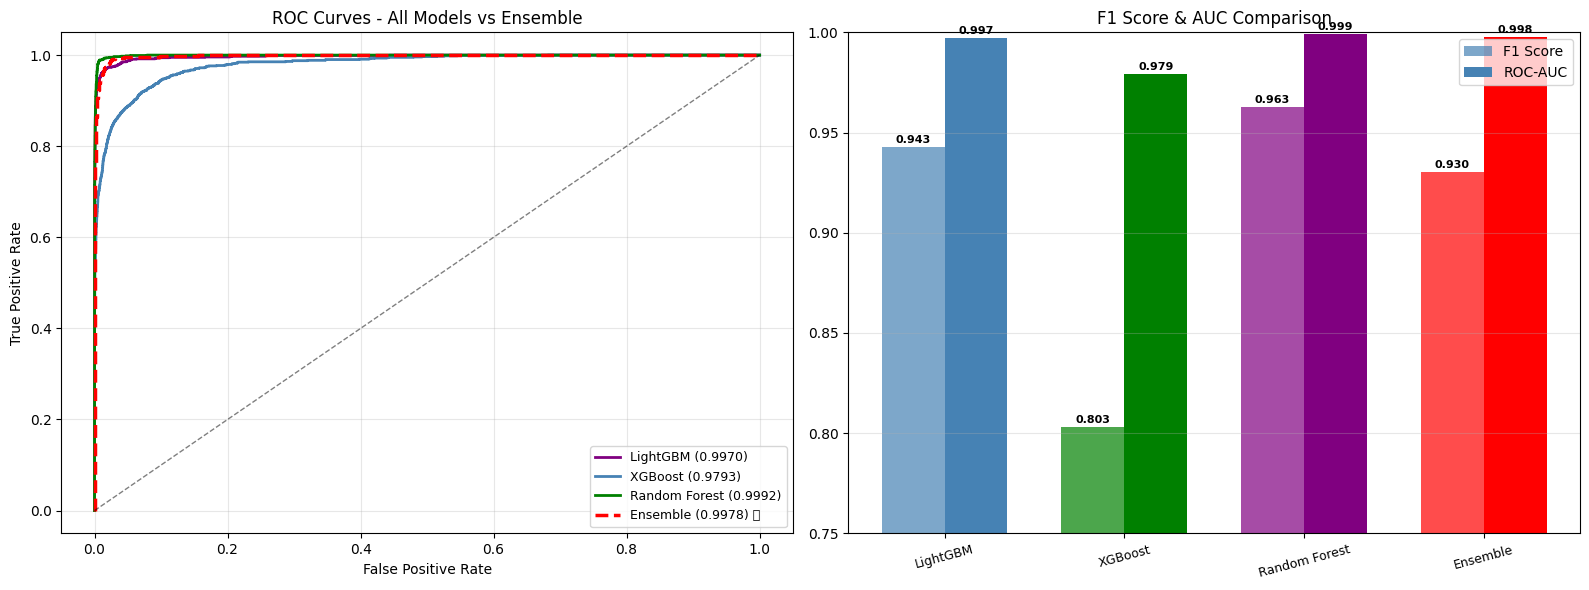

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = {
    'XGBoost'      : 'steelblue',
    'Random Forest': 'green',
    'LightGBM'     : 'purple'
}

# ROC Curves
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y, res['y_prob'])
    axes[0].plot(fpr, tpr, color=colors[name], lw=2,
                 label=f"{name} ({res['auc']:.4f})")

fpr_e, tpr_e, _ = roc_curve(y, ensemble_prob)
axes[0].plot(fpr_e, tpr_e, color='red', lw=2.5,
             linestyle='--',
             label=f"Ensemble ({ens_auc:.4f}) ")
axes[0].plot([0,1],[0,1],'k--', lw=1, alpha=0.5)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves - All Models vs Ensemble")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Bar Chart
all_names = list(results.keys()) + ['Ensemble']
all_f1s   = [results[n]['f1'] for n in results] + [ens_f1]
all_aucs  = [results[n]['auc'] for n in results] + [ens_auc]
bar_colors = list(colors.values()) + ['red']

x = np.arange(len(all_names))
w = 0.35

axes[1].bar(x - w/2, all_f1s,  w, label='F1 Score',
            color=bar_colors, alpha=0.7)
axes[1].bar(x + w/2, all_aucs, w, label='ROC-AUC',
            color=bar_colors, alpha=1.0)
axes[1].set_xticks(x)
axes[1].set_xticklabels(all_names, rotation=15, fontsize=9)
axes[1].set_ylim(0.75, 1.0)
axes[1].set_title("F1 Score & AUC Comparison")
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

for i, (f, a) in enumerate(zip(all_f1s, all_aucs)):
    axes[1].text(i - w/2, f + 0.002, f"{f:.3f}",
                 ha='center', fontsize=8, fontweight='bold')
    axes[1].text(i + w/2, a + 0.002, f"{a:.3f}",
                 ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Risk tier
def risk_tier(prob):
    if prob >= 0.7:   return 'Critical'
    elif prob >= 0.5: return 'High'
    elif prob >= 0.3: return 'Medium'
    else:             return 'Low'

model_data['churn_prob']      = ensemble_prob
model_data['churn_predicted'] = ensemble_pred
model_data['risk_tier']       = model_data['churn_prob'].apply(risk_tier)

master = master.merge(
    model_data[['Loyalty Number', 'churn_prob',
                'churn_predicted', 'risk_tier']],
    on='Loyalty Number', how='left'
)
master['churn_prob']      = master['churn_prob'].fillna(0)
master['churn_predicted'] = master['churn_predicted'].fillna(0)
master['risk_tier']       = master['risk_tier'].fillna('Low')

print("Risk Tier Distribution:")
print(master['risk_tier'].value_counts())
print(f"\nHigh+Critical: {master[master['risk_tier'].isin(['Critical','High'])].shape[0]:,}")

Risk Tier Distribution:
risk_tier
Low         15489
Critical      668
Medium        344
High          236
Name: count, dtype: int64

High+Critical: 904


In [ ]:
def get_recommendation(row):
    seg  = row.get('segment', 'Never Active')
    prob = row['churn_prob']
    clv  = row['CLV']
    card = row['Loyalty Card']
    eng  = row.get('engagement_ratio', 0)

    if seg == 'Core Flyers':
        if prob > 0.4 and eng < 0.4:
            return ('HIGH', 'Tier Protection Alert',
                    'Email: Tier upgrade fast-track + companion ticket',
                    'Within 7 days of engagement drop')
        return ('LOW', 'Loyalty Deepening',
                '2x points next 30 days + year-end summary',
                'Quarterly')

    elif seg == 'Drifting Loyalists':
        if prob > 0.4:
            return ('MEDIUM', 'Re-engagement Campaign',
                    '2x points next booking + personalized route email',
                    'Within 30 days of inactivity signal')
        return ('LOW', 'Seasonal Nudge',
                '1.5x points for advance summer/winter booking',
                'May 1st and November 1st')

    elif seg == 'Silent Attritors':
        if clv > 7000 and prob > 0.7:
            return ('CRITICAL', 'Last-Mile Win-Back',
                    f'{"Direct call + 3000 bonus points + 15% off" if card in ["Aurora","Nova"] else "Email + 1500 bonus points + 10% off"}',
                    '7 days; archive after 30 days no response')
        return ('LOW', 'Graceful Exit',
                'Final email: 500 points. Pause marketing after.',
                'Single send only')

    else:
        return ('LOW', 'Welcome Activation',
                'First flight incentive: 500 bonus points',
                'Monthly newsletter')

recs = master.apply(get_recommendation, axis=1)
master['priority']    = recs.apply(lambda x: x[0])
master['action']      = recs.apply(lambda x: x[1])
master['what_to_do']  = recs.apply(lambda x: x[2])
master['when_to_act'] = recs.apply(lambda x: x[3])

print("=== RECOMMENDATIONS SUMMARY ===")
print(master.groupby(['segment', 'priority', 'action'])
      .size().reset_index(name='count').to_string(index=False))

=== RECOMMENDATIONS SUMMARY ===
           segment priority                 action  count
       Core Flyers     HIGH  Tier Protection Alert    188
       Core Flyers      LOW      Loyalty Deepening  10161
Drifting Loyalists      LOW         Seasonal Nudge   2930
Drifting Loyalists   MEDIUM Re-engagement Campaign    537
      Never Active      LOW     Welcome Activation   1570
  Silent Attritors CRITICAL     Last-Mile Win-Back     58
  Silent Attritors      LOW          Graceful Exit   1293


In [ ]:
output_path = '/content/drive/MyDrive/airline_project/'

master.to_csv(output_path + 'master_final.csv', index=False)

at_risk = master[
    master['risk_tier'].isin(['Critical', 'High'])
].sort_values('churn_prob', ascending=False)
at_risk.to_csv(output_path + 'at_risk_customers.csv', index=False)

print(f"master_final.csv     : {len(master):,} rows ")
print(f"at_risk_customers.csv: {len(at_risk):,} rows ")
print("\nProject Complete! ")

master_final.csv     : 16,737 rows 
at_risk_customers.csv: 904 rows 

Project Complete! 


In [ ]:
print(master.columns.tolist())
print(master['segment'].unique())
print(master['risk_tier'].unique())
print(master.shape)

['Loyalty Number', 'Gender', 'Education', 'Salary', 'Marital Status', 'Loyalty Card', 'CLV', 'Enrollment Type', 'tenure_months', 'card_rank', 'churn', 'is_cancelled', 'behavioral_churn', 'never_flew', 'total_flights', 'total_distance', 'total_pts_earned', 'total_pts_redeemed', 'total_dollar_redeem', 'active_months', 'zero_months', 'max_flights_month', 'avg_flights_month', 'std_flights_month', 'recency_months', 'engagement_ratio', 'redemption_rate', 'avg_dist_per_flight', 'flights_2017', 'flights_h1_2018', 'activity_trend', 'fall', 'spring', 'summer', 'winter', 'gender_enc', 'edu_enc', 'marital_enc', 'promo_enc', 'segment', 'churn_prob', 'churn_predicted', 'risk_tier', 'priority', 'action', 'what_to_do', 'when_to_act']
['Core Flyers' 'Drifting Loyalists' 'Silent Attritors' 'Never Active']
['Low' 'High' 'Critical' 'Medium']
(16737, 47)


In [ ]:
dashboard_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

st.set_page_config(
    page_title="Airline Loyalty Intelligence",
    page_icon="✈️",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ── DARK THEME CSS ────────────────────────────────────────────
st.markdown("""
<style>
[data-testid="stAppViewContainer"] { background-color: #0f0f1a; }
[data-testid="stSidebar"]          { background-color: #1a1a2e; }
[data-testid="metric-container"]   { background-color: #1a1a2e; border-radius: 10px; padding: 10px; }
h1, h2, h3, p, label              { color: white !important; }
.stDataFrame                       { background-color: #1a1a2e; }
div[data-testid="stMetricValue"]   { color: white; font-size: 28px; }
div[data-testid="stMetricLabel"]   { color: #aaaaaa; }
.stSelectbox label, .stMultiSelect label { color: white !important; }
</style>
""", unsafe_allow_html=True)

# ── LOAD DATA ─────────────────────────────────────────────────
@st.cache_data
def load_data():
    return pd.read_csv("/content/drive/MyDrive/airline_project/master_final.csv")

df = load_data()

# ── SIDEBAR FILTERS ───────────────────────────────────────────
st.sidebar.markdown("## ✈️ Loyalty Intelligence")
st.sidebar.markdown("---")

seg_filter  = st.sidebar.multiselect(
    "Segment", df["segment"].unique(),
    default=df["segment"].unique()
)
risk_filter = st.sidebar.multiselect(
    "Risk Tier", ["Critical", "High", "Medium", "Low"],
    default=["Critical", "High", "Medium", "Low"]
)
card_filter = st.sidebar.multiselect(
    "Card Tier", df["Loyalty Card"].unique(),
    default=df["Loyalty Card"].unique()
)
clv_min, clv_max = st.sidebar.slider(
    "CLV Range ($)",
    int(df["CLV"].min()), int(df["CLV"].max()),
    (int(df["CLV"].min()), int(df["CLV"].max()))
)

filtered = df[
    df["segment"].isin(seg_filter) &
    df["risk_tier"].isin(risk_filter) &
    df["Loyalty Card"].isin(card_filter) &
    df["CLV"].between(clv_min, clv_max)
]

st.sidebar.markdown("---")
st.sidebar.markdown(f"**Showing:** {len(filtered):,} of {len(df):,} customers")

# ── HEADER ────────────────────────────────────────────────────
st.markdown("# ✈️ Airline Loyalty Intelligence Dashboard")
st.markdown("*Real-time churn prediction and retention action engine*")
st.markdown("---")

# ── TOP METRICS ───────────────────────────────────────────────
c1, c2, c3, c4, c5 = st.columns(5)
c1.metric("Total Members",    f"{len(filtered):,}")
c2.metric("Churn Rate",       f"{filtered['churn'].mean()*100:.1f}%")
c3.metric("Critical Risk",    f"{(filtered['risk_tier']=='Critical').sum():,}",
          delta="Needs immediate action", delta_color="inverse")
c4.metric("High Risk",        f"{(filtered['risk_tier']=='High').sum():,}")
c5.metric("Avg CLV",          f"${filtered['CLV'].mean():,.0f}")

st.markdown("---")

# ── TABS ──────────────────────────────────────────────────────
tab1, tab2, tab3, tab4 = st.tabs([
    "📊 Overview",
    "⚠️ At-Risk Customers",
    "👥 Segments",
    "📋 Retention Playbook"
])

SEG_COLORS = {
    "Core Flyers"       : "#4CAF50",
    "Drifting Loyalists": "#FF9800",
    "Silent Attritors"  : "#F44336",
    "Never Active"      : "#9E9E9E"
}

RISK_COLORS = {
    "Critical": "#F44336",
    "High"    : "#FF9800",
    "Medium"  : "#FFC107",
    "Low"     : "#4CAF50"
}

# ════════════════════════════════════════
# TAB 1: OVERVIEW
# ════════════════════════════════════════
with tab1:
    col1, col2 = st.columns(2)

    # Donut Chart
    seg_dist = filtered["segment"].value_counts().reset_index()
    seg_dist.columns = ["segment", "count"]
    fig_donut = go.Figure(go.Pie(
        labels=seg_dist["segment"],
        values=seg_dist["count"],
        hole=0.6,
        marker_colors=[SEG_COLORS.get(s, "gray") for s in seg_dist["segment"]]
    ))
    fig_donut.update_layout(
        title="Segment Distribution",
        paper_bgcolor="#1a1a2e", plot_bgcolor="#1a1a2e",
        font_color="white", height=380,
        legend=dict(font=dict(color="white"))
    )
    col1.plotly_chart(fig_donut, use_container_width=True)

    # Churn Risk Distribution
    fig_hist = px.histogram(
        filtered, x="churn_prob", color="segment",
        nbins=25, title="Churn Risk Distribution",
        color_discrete_map=SEG_COLORS,
        barmode="overlay", opacity=0.75,
        labels={"churn_prob": "Churn Probability", "count": "Customers"}
    )
    fig_hist.update_layout(
        paper_bgcolor="#1a1a2e", plot_bgcolor="#1a1a2e",
        font_color="white", height=380
    )
    col2.plotly_chart(fig_hist, use_container_width=True)

    col3, col4 = st.columns(2)

    # Churn Rate by Segment Bar
    seg_churn = filtered.groupby("segment").agg(
        churn_rate=("churn", "mean"),
        count=("churn", "count")
    ).reset_index()
    seg_churn["churn_pct"] = (seg_churn["churn_rate"] * 100).round(1)

    fig_bar = px.bar(
        seg_churn, x="segment", y="churn_pct",
        color="segment", color_discrete_map=SEG_COLORS,
        title="Churn Rate by Segment (%)",
        text="churn_pct",
        labels={"churn_pct": "Churn %", "segment": "Segment"}
    )
    fig_bar.update_traces(texttemplate="%{text}%", textposition="outside")
    fig_bar.update_layout(
        paper_bgcolor="#1a1a2e", plot_bgcolor="#1a1a2e",
        font_color="white", height=350, showlegend=False
    )
    col3.plotly_chart(fig_bar, use_container_width=True)

    # CLV vs Churn Prob Scatter
    sample = filtered.sample(min(2000, len(filtered)), random_state=42)
    fig_scatter = px.scatter(
        sample, x="engagement_ratio", y="CLV",
        color="risk_tier",
        color_discrete_map=RISK_COLORS,
        title="CLV vs Engagement (by Risk Tier)",
        opacity=0.6, size_max=5,
        labels={"engagement_ratio": "Engagement Ratio", "CLV": "CLV ($)"}
    )
    fig_scatter.update_layout(
        paper_bgcolor="#1a1a2e", plot_bgcolor="#1a1a2e",
        font_color="white", height=350
    )
    col4.plotly_chart(fig_scatter, use_container_width=True)

# ════════════════════════════════════════
# TAB 2: AT-RISK CUSTOMERS
# ════════════════════════════════════════
with tab2:
    st.markdown("### ⚠️ High Priority Customers - Immediate Action Required")

    risk_level = st.radio(
        "Filter by Risk",
        ["All", "Critical Only", "Critical + High"],
        horizontal=True
    )

    if risk_level == "Critical Only":
        at_risk = filtered[filtered["risk_tier"] == "Critical"]
    elif risk_level == "Critical + High":
        at_risk = filtered[filtered["risk_tier"].isin(["Critical", "High"])]
    else:
        at_risk = filtered[filtered["churn_prob"] > 0.3]

    at_risk = at_risk.sort_values("churn_prob", ascending=False)

    st.markdown(f"**{len(at_risk):,} customers need attention**")

    display_cols = {
        "Loyalty Number" : "ID",
        "Loyalty Card"   : "Card",
        "CLV"            : "CLV ($)",
        "segment"        : "Segment",
        "churn_prob"     : "Churn Risk",
        "risk_tier"      : "Risk Tier",
        "action"         : "Action",
        "what_to_do"     : "What To Do",
        "when_to_act"    : "When"
    }

    show_df = at_risk[list(display_cols.keys())].copy()
    show_df["churn_prob"] = (show_df["churn_prob"] * 100).round(1).astype(str) + "%"
    show_df["CLV ($)"]    = show_df["CLV"].apply(lambda x: f"${x:,.0f}")
    show_df = show_df.drop(columns=["CLV"]).rename(columns=display_cols)

    st.dataframe(show_df, use_container_width=True, height=450)

    # Download button
    csv = at_risk.to_csv(index=False).encode("utf-8")
    st.download_button(
        label="⬇️ Download At-Risk List",
        data=csv,
        file_name="at_risk_customers.csv",
        mime="text/csv"
    )

# ════════════════════════════════════════
# TAB 3: SEGMENTS
# ════════════════════════════════════════
with tab3:
    st.markdown("### 👥 Segment Deep Dive")

    seg_cols = st.columns(4)
    segs = ["Core Flyers", "Drifting Loyalists", "Silent Attritors", "Never Active"]
    emojis = ["🏆", "🟡", "🔴", "💤"]

    for col, seg, emoji in zip(seg_cols, segs, emojis):
        grp = filtered[filtered["segment"] == seg]
        if len(grp) == 0:
            continue
        color = SEG_COLORS[seg]
        col.markdown(f"""
        <div style="background:#1a1a2e; border-left:4px solid {color};
                    border-radius:10px; padding:15px; margin:5px">
            <h4 style="color:{color}; margin:0">{emoji} {seg}</h4>
            <h2 style="margin:5px 0; color:white">{len(grp):,}</h2>
            <p style="color:#aaa; margin:0">
                {len(grp)/len(df)*100:.1f}% of base<br>
                {grp["churn"].mean()*100:.1f}% churn rate
            </p>
            <hr style="border-color:#333; margin:10px 0">
            <small style="color:#ddd">
                Avg flights: {grp["total_flights"].mean():.1f}<br>
                Engagement: {grp["engagement_ratio"].mean()*100:.1f}%<br>
                Avg CLV: ${grp["CLV"].mean():,.0f}<br>
                Avg recency: {grp["recency_months"].mean():.1f} mo
            </small>
        </div>
        """, unsafe_allow_html=True)

    st.markdown("---")

    # Segment selected for deep dive
    selected_seg = st.selectbox("Select Segment for Deep Dive", segs)
    seg_data = filtered[filtered["segment"] == selected_seg]

    sc1, sc2 = st.columns(2)

    # CLV Distribution for segment
    fig_clv = px.histogram(
        seg_data, x="CLV", nbins=30,
        title=f"CLV Distribution - {selected_seg}",
        color_discrete_sequence=[SEG_COLORS[selected_seg]]
    )
    fig_clv.update_layout(
        paper_bgcolor="#1a1a2e", plot_bgcolor="#1a1a2e",
        font_color="white", height=300
    )
    sc1.plotly_chart(fig_clv, use_container_width=True)

    # Recency Distribution
    fig_rec = px.histogram(
        seg_data, x="recency_months", nbins=20,
        title=f"Recency Distribution - {selected_seg}",
        color_discrete_sequence=[SEG_COLORS[selected_seg]]
    )
    fig_rec.update_layout(
        paper_bgcolor="#1a1a2e", plot_bgcolor="#1a1a2e",
        font_color="white", height=300
    )
    sc2.plotly_chart(fig_rec, use_container_width=True)

# ════════════════════════════════════════
# TAB 4: RETENTION PLAYBOOK
# ════════════════════════════════════════
with tab4:
    st.markdown("### 📋 Retention Playbook - Segment Wise Actions")

    playbooks = {
        "Core Flyers": {
            "color"   : "#4CAF50",
            "risk"    : "Low Risk",
            "strategy": "Loyalty Deepening",
            "trigger" : "Engagement ratio drops below 40% for 2 consecutive months",
            "action"  : "Tier upgrade fast-track + companion ticket on milestone flight",
            "timeline": "Quarterly check; act within 7 days of trigger",
            "kpi"     : "Tier upgrade rate + Avg flights per quarter",
            "expected": "Maintain churn < 5%"
        },
        "Drifting Loyalists": {
            "color"   : "#FF9800",
            "risk"    : "Medium Risk",
            "strategy": "Re-engagement Campaign",
            "trigger" : "Churn prob > 40% AND no flights in 3+ months",
            "action"  : "2x points on next booking + personalized route email based on past travel",
            "timeline": "Within 30 days of inactivity signal",
            "kpi"     : "% flying within 60 days of outreach",
            "expected": "25% re-activation rate"
        },
        "Silent Attritors": {
            "color"   : "#F44336",
            "risk"    : "Critical",
            "strategy": "Last-Mile Save or Graceful Exit",
            "trigger" : "Recency > 24 months AND churn prob > 70%",
            "action"  : "Aurora/Nova: Direct call + 3000 points + 15% off. Star: Email + 1500 points",
            "timeline": "One attempt in 7 days; archive after 30 days no response",
            "kpi"     : "Win-back rate vs cost per recovered customer vs CLV",
            "expected": "8% win-back; pause spend on non-responders"
        },
        "Never Active": {
            "color"   : "#9E9E9E",
            "risk"    : "Activation Needed",
            "strategy": "Welcome Activation",
            "trigger" : "Joined but never flew",
            "action"  : "500 bonus points on first booking + onboarding email series",
            "timeline": "Month 1, 2, 3 after joining",
            "kpi"     : "First flight conversion rate",
            "expected": "20% first flight activation"
        }
    }

    p_cols = st.columns(2)
    for i, (seg, pb) in enumerate(playbooks.items()):
        col = p_cols[i % 2]
        grp = filtered[filtered["segment"] == seg]
        col.markdown(f"""
        <div style="background:#1a1a2e; border-radius:12px;
                    border-top:4px solid {pb['color']};
                    padding:20px; margin:10px 0">
            <div style="display:flex; justify-content:space-between; align-items:center">
                <h3 style="color:{pb['color']}; margin:0">{seg}</h3>
                <span style="background:{pb['color']}33; color:{pb['color']};
                             padding:4px 12px; border-radius:20px; font-size:12px">
                    {pb['risk']}
                </span>
            </div>
            <p style="color:#888; margin:5px 0">{len(grp):,} customers · {grp["churn"].mean()*100:.1f}% churn</p>
            <hr style="border-color:#333">
            <b style="color:white">📌 Strategy:</b>
            <p style="color:#ddd">{pb['strategy']}</p>
            <b style="color:white">🎯 Trigger:</b>
            <p style="color:#ddd">{pb['trigger']}</p>
            <b style="color:white">⚡ Action:</b>
            <p style="color:#ddd">{pb['action']}</p>
            <b style="color:white">⏰ Timeline:</b>
            <p style="color:#ddd">{pb['timeline']}</p>
            <b style="color:white">📊 KPI:</b>
            <p style="color:#ddd">{pb['kpi']}</p>
            <div style="background:{pb['color']}22; border-radius:8px; padding:8px; margin-top:10px">
                <b style="color:{pb['color']}">Expected: </b>
                <span style="color:#ddd">{pb['expected']}</span>
            </div>
        </div>
        """, unsafe_allow_html=True)

    # Customer Lookup
    st.markdown("---")
    st.markdown("### 🔍 Customer Lookup")
    cust_id = st.number_input("Enter Customer ID (Loyalty Number)",
                               min_value=int(df["Loyalty Number"].min()),
                               max_value=int(df["Loyalty Number"].max()),
                               step=1)

    if st.button("🔍 Search Customer"):
        cust = df[df["Loyalty Number"] == cust_id]
        if len(cust) == 0:
            st.error("Customer not found!")
        else:
            cust = cust.iloc[0]
            risk_color = RISK_COLORS.get(cust["risk_tier"], "gray")
            st.markdown(f"""
            <div style="background:#1a1a2e; border-radius:12px;
                        border-left:5px solid {risk_color}; padding:20px">
                <h3 style="color:white">Customer #{int(cust['Loyalty Number'])}</h3>
                <div style="display:grid; grid-template-columns:1fr 1fr 1fr; gap:15px">
                    <div>
                        <p style="color:#aaa; margin:0">Card Tier</p>
                        <h4 style="color:white; margin:0">{cust['Loyalty Card']}</h4>
                    </div>
                    <div>
                        <p style="color:#aaa; margin:0">CLV</p>
                        <h4 style="color:white; margin:0">${cust['CLV']:,.0f}</h4>
                    </div>
                    <div>
                        <p style="color:#aaa; margin:0">Segment</p>
                        <h4 style="color:{SEG_COLORS.get(cust['segment'],'white')}; margin:0">{cust['segment']}</h4>
                    </div>
                    <div>
                        <p style="color:#aaa; margin:0">Churn Risk</p>
                        <h4 style="color:{risk_color}; margin:0">{cust['churn_prob']*100:.1f}% ({cust['risk_tier']})</h4>
                    </div>
                    <div>
                        <p style="color:#aaa; margin:0">Last Flight</p>
                        <h4 style="color:white; margin:0">{cust['recency_months']:.0f} months ago</h4>
                    </div>
                    <div>
                        <p style="color:#aaa; margin:0">Engagement</p>
                        <h4 style="color:white; margin:0">{cust['engagement_ratio']*100:.1f}%</h4>
                    </div>
                </div>
                <hr style="border-color:#333; margin:15px 0">
                <b style="color:{risk_color}">Recommended Action: {cust['action']}</b>
                <p style="color:#ddd; margin:5px 0">{cust['what_to_do']}</p>
                <p style="color:#aaa; margin:0">⏰ {cust['when_to_act']}</p>
            </div>
            """, unsafe_allow_html=True)
'''

with open("/content/drive/MyDrive/airline_project/app.py", "w") as f:
    f.write(dashboard_code)

print("app.py saved to Drive ✅")

app.py saved to Drive ✅


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
path = '/content/drive/MyDrive/airline_project/'
print(os.listdir(path))

['Customer Flight Activity.csv', 'Calendar.csv', 'Airline Loyalty Data Dictionary.csv', 'Customer Loyalty History.csv', 'master_final.csv', 'at_risk_customers.csv', 'app.py']


In [ ]:
from google.colab import files
files.download('/content/drive/MyDrive/airline_project/master_final.csv')
files.download('/content/drive/MyDrive/airline_project/app.py')
print("Downloaded ")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded 
